# Download dataset

In [1]:
import os
import kagglehub
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Define download path
os.environ["KAGGLEHUB_CACHE"] = "../datasets"

# Download dataset
path = kagglehub.dataset_download("adilshamim8/social-media-addiction-vs-relationships")
csv_file = os.path.join(path, "Students Social Media Addiction.csv")
df = pd.read_csv(csv_file)
print('\ndataset downloaded at ', path)
print('reading file...')

/home/tenth/Documents/repos/pause-student-social-media-addiction-eda/eda.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



dataset downloaded at  ../datasets/datasets/adilshamim8/social-media-addiction-vs-relationships/versions/3
reading file...


# General dataset exploration

In [2]:
print('*'*30)
print('GENERAL DATASET INFORMATION')
print('*'*30)

print('Columns and records count:')
df.info()
df.describe()
print('*'*30)

print('Gender distribution:')
print(df['Gender'].value_counts())
print('*'*30)

print('Age calculations:')
print(f"mean:\t {df['Age'].mean():.1f}")
print('median:\t', df['Age'].median())
print('*'*30)

print('Countries data:')
print('unique count:\t', df['Country'].nunique()) # len(df['Country'].unique())

******************************
GENERAL DATASET INFORMATION
******************************
Columns and records count:
<class 'pandas.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    str    
 3   Academic_Level                705 non-null    str    
 4   Country                       705 non-null    str    
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    str    
 7   Affects_Academic_Performance  705 non-null    str    
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    str    
 11  Conflicts_Over_So

## Methodology
This section provides a brief explanation of the techniques used in this EDA, along with how questions have been raised and how the graphs are plotted to provide insights to answer them.

### Univariate analysis
Graphs are plotted based on **one feature at a time**, in order to understand its distribution over the dataset. Histograms and boxplots are used to visualize characteristics such as central tendency, dispersion, outliers, noise and errors in the dataset.
Understanding the distribution of features is important because it can determine if the data approximates a normal distribution. Additionally, identifying distribution patterns provides useful context for later correlation analysis.

### Bivariate analysis
Graphs are plotted based on **two features at a time**, for determining empirical relationship between them. Scatterplots, correlation matrices and distribution over X and Y axis. Understanding these relationships can identify features that are more likely to drive others.

### Multivariate analysis
TODO

### Key insights and final considerations
TODO

---

## Univariate analysis
This section investigates the distribution of individual variables within the dataset.
The following features were selected for inspection:
- Avg_Daily_Usage_Hours
- Sleep_Hours_Per_Night
- Age

### Feature distributions and symmetry analysis

Distribution of the Avg_Daily_Usage_Hours column


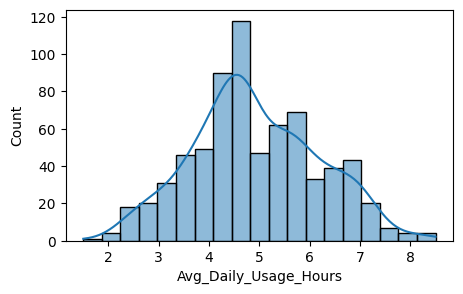

In [3]:
print('Distribution of the Avg_Daily_Usage_Hours column')
plt.figure(figsize=(5, 3))
sns.histplot(
    data=df, 
    x='Avg_Daily_Usage_Hours', 
    kde=True, 
    bins='auto'
)
plt.show()

This plot depicts a histogram highlighting the distribution of the Avg_Daily_Usage_Hours feature.
These results shows an approximately symmetric, but slightly skewed distribution.

Distribution of the Sleep_Hours_Per_Night column


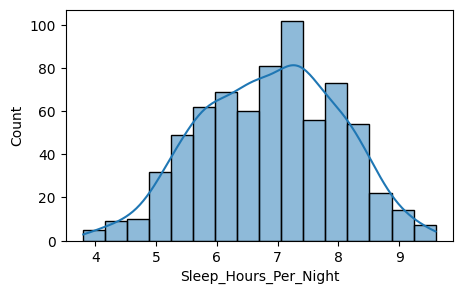

In [4]:
print('Distribution of the Sleep_Hours_Per_Night column')
plt.figure(figsize=(5, 3))
sns.histplot(
    data=df, 
    x='Sleep_Hours_Per_Night', 
    kde=True, 
    bins='auto'
)
plt.show()

Similarly, this plot depicts a histogram highlighting the distribution of the Sleep_Hours_Per_Night feature.
The distribution of the values are close enough to normal distribution, although a little bit skewed to the right.

Distribution of the Age column


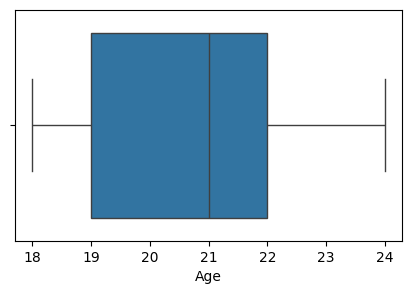

In [5]:
print('Distribution of the Age column')
plt.figure(figsize=(5, 3))
sns.boxplot(data=df, x='Age')
plt.show()

The boxplot suggests a relatively symmetric distribution with no evident outliers, though the exact distribution shape cannot be inferred solely from this visualization.

Gender
Female    353
Male      352
Name: count, dtype: int64
['50.1' '49.9']
Affects_Academic_Performance
Yes    453
No     252
Name: count, dtype: int64
['64.3' '35.7']


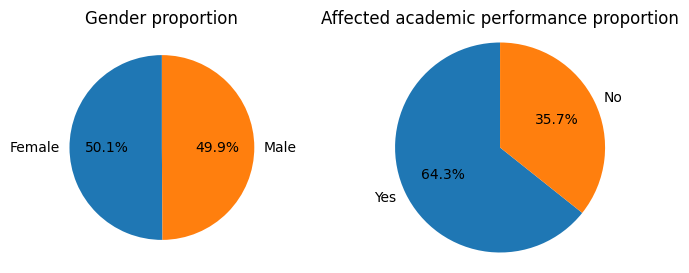

In [17]:
print(df['Gender'].value_counts())
normalized_gender_percentages = (df['Gender'].value_counts(normalize=True).mul(100).round(1).astype(float))
print(df['Gender'].value_counts(normalize=True).mul(100).round(1).astype(str).to_numpy())

fig, (ax0,ax1) = plt.subplots(1, 2, figsize=(8,3))

ax0.pie(
    normalized_gender_percentages.to_numpy(),
    labels = ['Female', 'Male'],
    autopct='%1.1f%%',
    startangle=90,
)
ax0.set_title('Gender proportion')


print(df['Affects_Academic_Performance'].value_counts())
normalized_gender_percentages = (df['Affects_Academic_Performance'].value_counts(normalize=True).mul(100).round(1).astype(float))
print(df['Affects_Academic_Performance'].value_counts(normalize=True).mul(100).round(1).astype(str).to_numpy())
ax1.pie(
    normalized_gender_percentages.to_numpy(),
    labels = ['Yes', 'No'],
    autopct='%1.1f%%',
    startangle=90,
)
ax1.set_title('Affected academic performance proportion')

plt.axis('equal')
plt.show()


#### Demographic analysis

How does the country distribution affect the dataset? The main goal for this section is to uncover if there is any unbalanced data country-wise.

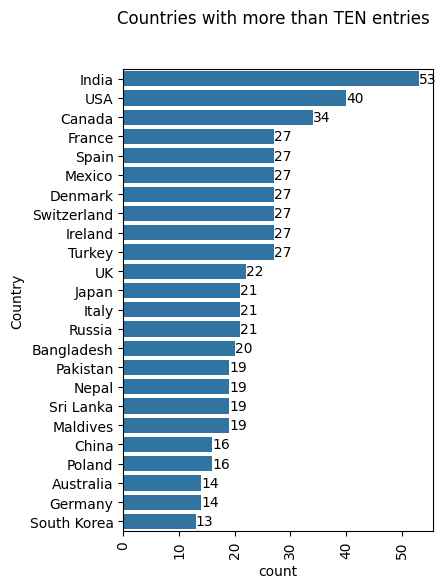

Countries that has ten or more records:  24
Which is only 21.8% of the 110 countries present.


In [19]:
n = 10
countries_entries_greater_than_x = df['Country'].value_counts()[df['Country'].value_counts() > n].index #more than 10 records for simplicity
plt.figure(figsize=(4, 6))
ax = sns.countplot(
    data=df, 
    y='Country',
    order=countries_entries_greater_than_x.value_counts().index
)
plt.suptitle("Countries with more than TEN entries")
ax.bar_label(ax.containers[0])
plt.xticks(rotation=90)
plt.show()
print('Countries that has ten or more records: ', len(df['Country'].value_counts()[df['Country'].value_counts() > n].index))
print(f"Which is only {(len(df['Country'].value_counts()[df['Country'].value_counts() > n].index) / df['Country'].nunique()) * 100:.1f}% of the 110 countries present.")

## Bivariate Analysis

This section presents plots between two features that (potentially) correlate and can present insights not seen before about the data.

#### Countries


                Avg_usage
Country                  
USA              6.890000
UAE              6.725000
Mexico           6.422222
Ecuador          6.300000
India            6.116981
Czech Republic   6.100000
Thailand         5.900000
Armenia          5.900000
Brazil           5.887500
Nigeria          5.800000


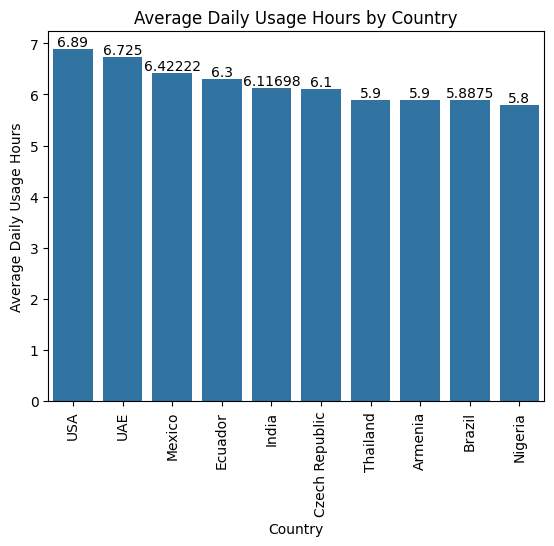

In [8]:
grouped_df = df.groupby(by="Country").agg(Avg_usage=('Avg_Daily_Usage_Hours', 'mean')).sort_values(by="Avg_usage", ascending=False).head(10)
print(grouped_df)
ax = sns.barplot(
    data=grouped_df,
    x="Country",
    y="Avg_usage"
)
ax.bar_label(ax.containers[0])

plt.xticks(rotation=90)   # rotate country names so they fit
plt.xlabel("Country")

plt.ylabel("Average Daily Usage Hours")
plt.title("Average Daily Usage Hours by Country")

plt.show()

#### Platform usage and Average daily usage

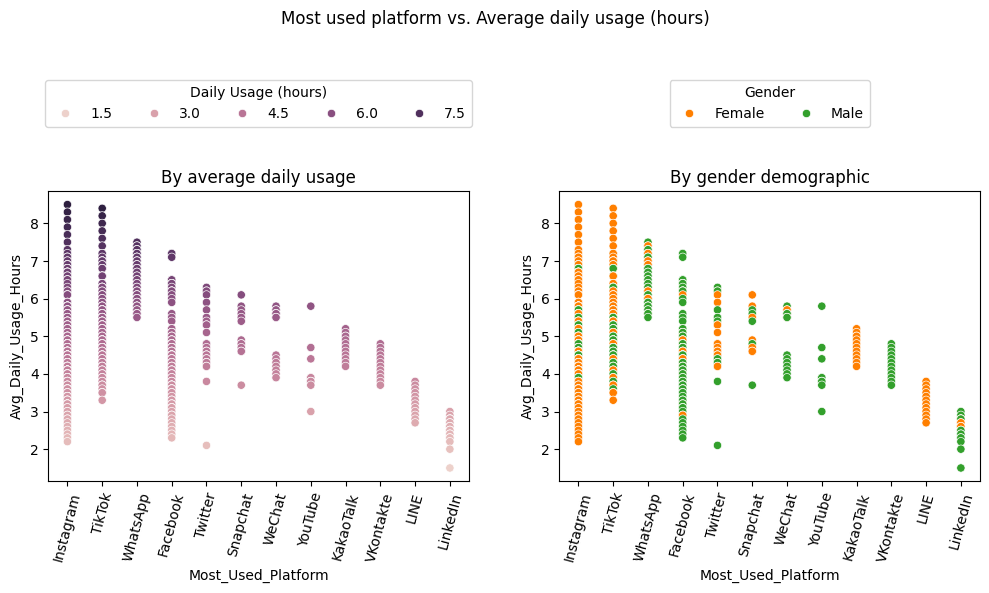

In [ ]:
df_sorted = df.sort_values(by="Avg_Daily_Usage_Hours", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(10,6))
ax1 = sns.scatterplot(
    data=df_sorted,
    x='Most_Used_Platform',
    y='Avg_Daily_Usage_Hours',
    hue='Avg_Daily_Usage_Hours',
    ax=axes[0]
)
ax1.set_title("By average daily usage")
axes[0].tick_params(axis='x', rotation=75)
sns.move_legend(
    ax1, "lower center",
    bbox_to_anchor=(.5, 1.2), ncol=5,
    title='Daily Usage (hours)', frameon=True
)

ax2 = sns.scatterplot(
    data=df_sorted,
    x='Most_Used_Platform',
    y='Avg_Daily_Usage_Hours',
    hue='Gender',
    palette="Paired_r",
    ax=axes[1]
)
ax2.set_title("By gender demographic")
axes[1].tick_params(axis='x', rotation=75)
sns.move_legend(
    ax2, "lower center",
    bbox_to_anchor=(.5, 1.2), ncol=5,
    title='Gender', frameon=True
)
plt.suptitle("Most used platform vs. Average daily usage (hours)")
plt.tight_layout()
plt.show()

Correlation between most used platforms vs. the daily usage shows that the Instagram and Tiktok are the most used platforms in the sample, it also shows the variety of the time spent by students in these social media applications.
These plots shows the same data under different perspectives, the first dsiplay the time spent by hours, while the latter highlight the gender that uses each platform the most.

### Correlation table
This correlation table between the numerical features emphasizes many strong potential connections that can be correlated to provide more insights and different perspective.

Which can be read like this:

<div align="center">

| Correlation (r) | Type |
|:-----------------:|------|
| 0.90 to 1.00 | Very strong positive |
| 0.70 to 0.89 | Strong positive |
| 0.40 to 0.69 | Moderate positive |
| 0.10 to 0.39 | Weak positive |
| -0.09 to 0.09 | No correlation |
| -0.10 to -0.39 | Weak negative |
| -0.40 to -0.69 | Moderate negative |
| -0.70 to -0.89 | Strong negative |
| -0.90 to -1.00 | Very strong negative |
</div>

e.g.: As Avg_Daily_Usage_Hours increases, Sleep_Hours_Per_Night strongly decreases (will be shown later on regresstion plots).


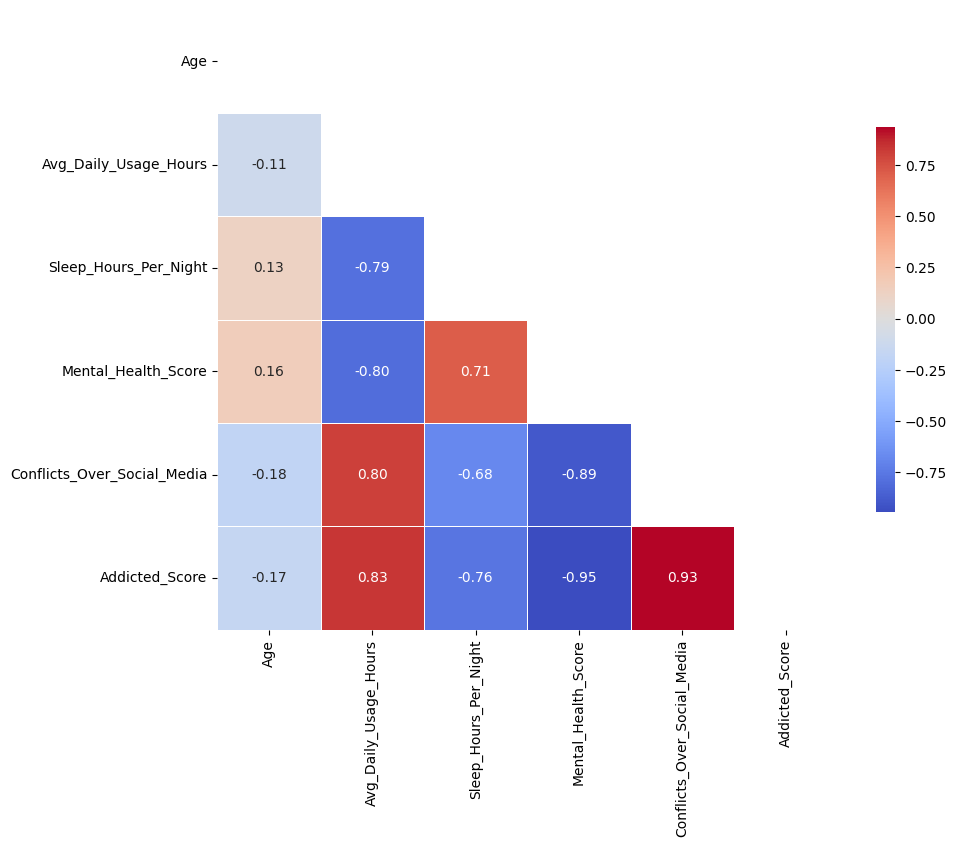

In [10]:
df_numeric = df.select_dtypes(['number'])
df_noIds = df_numeric.drop(columns=['Student_ID'])
corr_matrix = df_noIds.corr()

plt.figure(figsize=(10, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.show()

These correlation coefficients provide some insights about how the features interact with each other.

Examples:

Avg_Daily_Usage_Hours shows strong correlation with several other features:
- Mental_Health_Score
- Sleep_Hours_Per_Night
- Addicted_Score
- Conflicts_Over_Social_Media

Which can be seen as a behavioral association, because usage hours tends to be associated with:
- Worse mental health
- Less sleep (quantity/quality)
- Higher addiction score
- More conflicts

### Plotting the regression plots using Avg_Daily_Usage_Hours as pinpoint

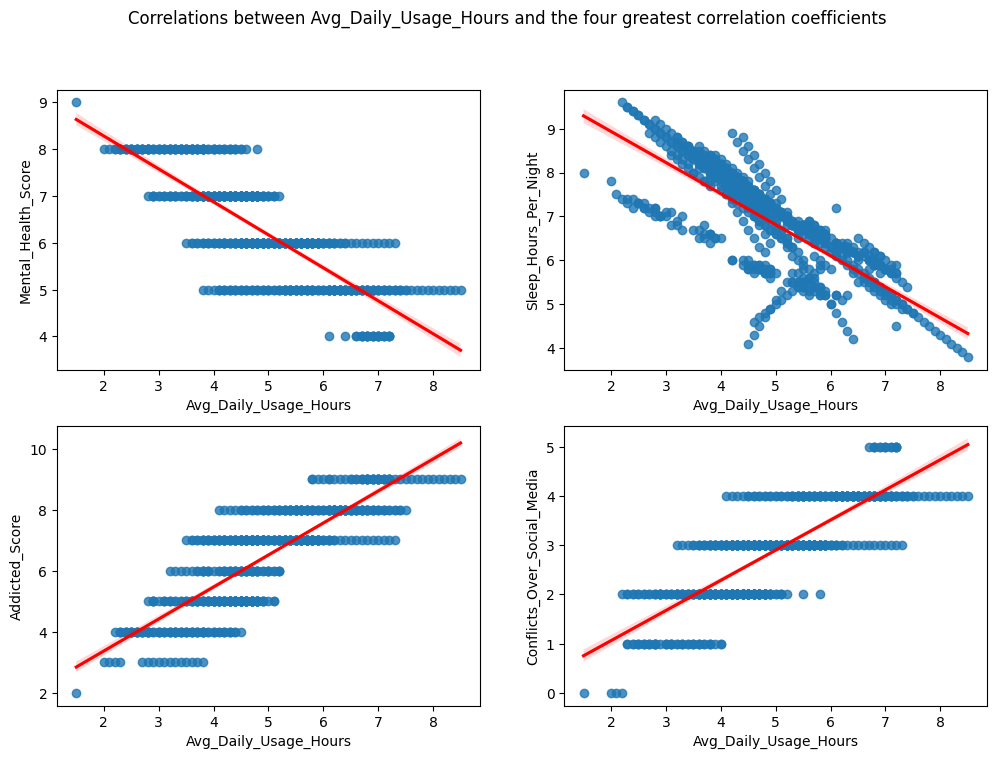

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))
ax0 = sns.regplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Mental_Health_Score',
    order=1,
    ax=axes[0][0],
    line_kws=dict(color="r")
)
ax1 = sns.regplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Sleep_Hours_Per_Night',
    order=1,
    ax=axes[0][1],
    line_kws=dict(color="r")
)
ax2 = sns.regplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Addicted_Score',
    order=1,
    ax=axes[1][0],
    line_kws=dict(color="r")
)

ax2 = sns.regplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Conflicts_Over_Social_Media',
    order=1,
    ax=axes[1][1],
    line_kws=dict(color="r")
)
plt.suptitle("Correlations between Avg_Daily_Usage_Hours and the four greatest correlation coefficients")

plt.show()

#### Sleep hours vs. Daily usage (hours) deeper analysis

This section provides a deeper analysis of the regression plot above (second plot, specifically). The goal is to visualize the same plot under different perspectives. Then subdivide the dataframe to obtain even more information. 

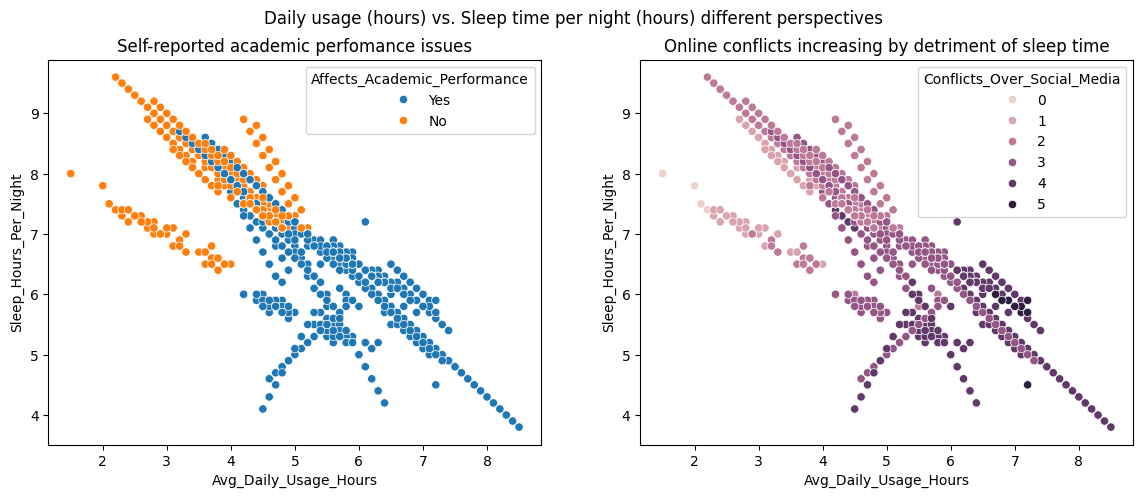

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
ax1 = sns.scatterplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Sleep_Hours_Per_Night',
    hue='Affects_Academic_Performance',
    ax=axes[0]
)
ax1.set_title("Self-reported academic perfomance issues")

ax2 = sns.scatterplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Sleep_Hours_Per_Night',
    hue='Conflicts_Over_Social_Media',
    ax=axes[1]
)
ax2.set_title("Online conflicts increasing by detriment of sleep time")
plt.suptitle("Daily usage (hours) vs. Sleep time per night (hours) different perspectives")
plt.show()

#### Subdividing the dataframe

By subdividing the data frame in two portions, it's possible to dive deeper and highlight insights about the data demographic. In these next two plots, the data is subdivised into: Those who claimed academic performance issues due to the social media addiction, and those who claimed no academic performance issues.

Question can be raised just like the following:
- In which academic level students reported affected academic performance the most?
- In which academic level students reported not being affected by social media addiction?

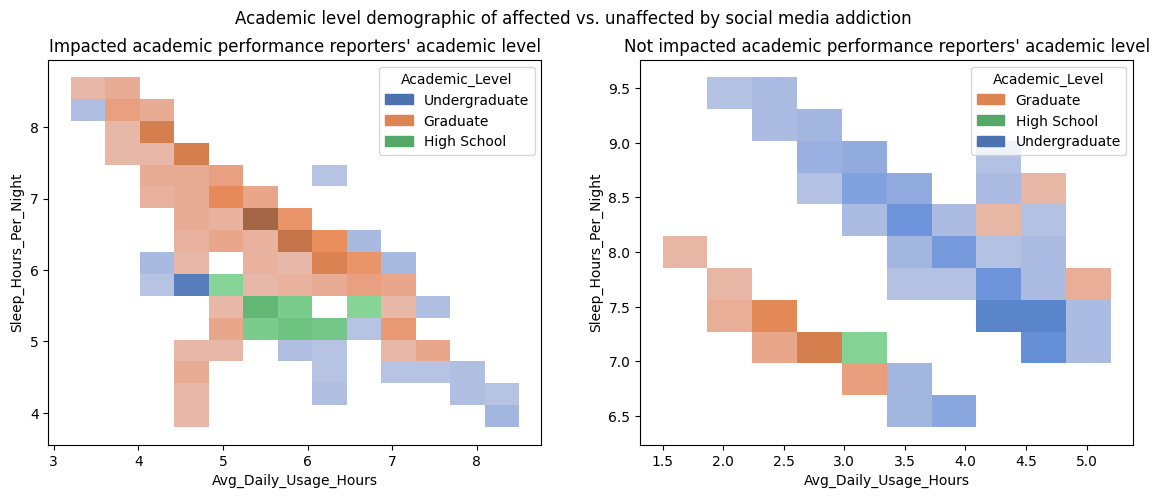

In [13]:
# Dataframe subdivisions
sub_df_self_reported_academic_performance_problems = df[df['Affects_Academic_Performance'] == 'Yes']
sub_df_self_reported_academic_performance_no_problems = df[df['Affects_Academic_Performance'] == 'No']

custom_palette = {
    "High School": "#55a868",
    "Undergraduate": "#4c72b0",
    "Graduate": "#dd8452"
}

fig, axes = plt.subplots(1, 2, figsize=(14,5))

ax3 = sns.histplot(
    data=sub_df_self_reported_academic_performance_problems,
    x='Avg_Daily_Usage_Hours',
    y='Sleep_Hours_Per_Night',
    hue='Academic_Level',
    ax=axes[0],
    palette=custom_palette
)
ax3.set_title("Impacted academic performance reporters' academic level")

ax4 = sns.histplot(
    data=sub_df_self_reported_academic_performance_no_problems,
    x='Avg_Daily_Usage_Hours',
    y='Sleep_Hours_Per_Night',
    hue='Academic_Level',
    ax=axes[1],
    palette=custom_palette
)
ax4.set_title("Not impacted academic performance reporters' academic level")
plt.suptitle("Academic level demographic of affected vs. unaffected by social media addiction")
plt.show()

The majority of responses shows that, Graduate academic level students are the majority who self-reported negative impact in their academic life. While most Undergraduate self-reported no impact.
It's also possible to check the difference in daily usage for both groups.

### Plotting regression plot using Addicted_Score as pinpoint

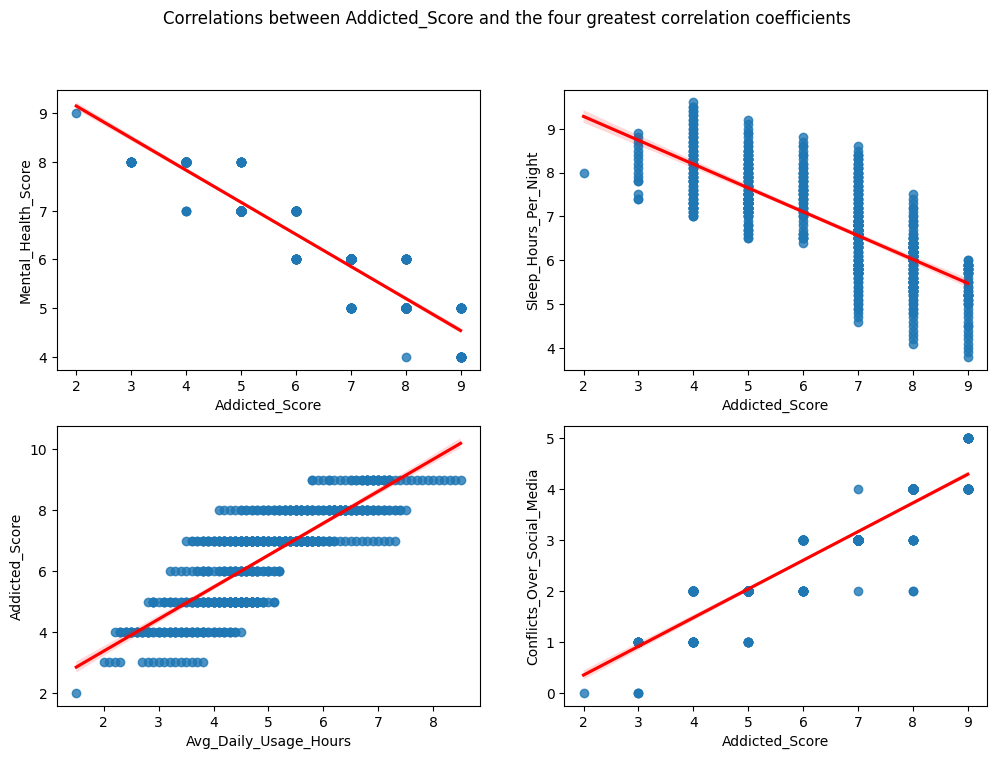

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))
ax0 = sns.regplot(
    data=df,
    x='Addicted_Score',
    y='Mental_Health_Score',
    order=1,
    ax=axes[0][0],
    line_kws=dict(color="r")
)
ax1 = sns.regplot(
    data=df,
    x='Addicted_Score',
    y='Sleep_Hours_Per_Night',
    order=1,
    ax=axes[0][1],
    line_kws=dict(color="r")
)
ax2 = sns.regplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Addicted_Score',
    order=1,
    ax=axes[1][0],
    line_kws=dict(color="r")
)

ax2 = sns.regplot(
    data=df,
    x='Addicted_Score',
    y='Conflicts_Over_Social_Media',
    order=1,
    ax=axes[1][1],
    line_kws=dict(color="r")
)
plt.suptitle("Correlations between Addicted_Score and the four greatest correlation coefficients")

plt.show()